In [14]:
import numpy as np
import time
import timeit
import random
import pandas as pd

In [15]:
def mat_prod(A: np.ndarray, B: np.ndarray):
    A_nrow, A_ncol = A.shape
    B_nrow, B_ncol = B.shape
    
    if A_ncol != B_nrow:
        print("Não é possível multiplicar essas matrizes.")
        return
    
    C = np.zeros((A_nrow, B_ncol))
    for i in range(A_nrow):
        for j in range(B_ncol):
            C[i,j] = sum(A[i,k]*B[k,j] for k in range(A_ncol))
    
    return C

In [16]:
def mat_dot_prod(A: np.ndarray, B: np.ndarray):
    A_nrow, A_ncol = A.shape
    B_nrow, B_ncol = B.shape
    
    if A_ncol != B_nrow:
        print("Não é possível multiplicar essas matrizes.")
        return
    
    C = np.zeros((A_nrow, B_ncol))
    for i in range(A_nrow):
        for j in range(B_ncol):
            C[i,j] = np.dot(A[i,:],B[:,j])
    
    return C

In [17]:
def benchmark(func, *args, num_times = 2):
    for i in range(2):
        func(*args)
    
    arr = np.zeros(num_times)
    
    for i in range(num_times):
        initial_time = time.perf_counter()
        func(*args)
        final_time = time.perf_counter()
        
        arr[i] = final_time - initial_time
        
    min = arr.min()
    
    return min

In [46]:
def calcularTempo_numpy(A, B, num_times= 5):
    for i in range(5):
        A@B
    
    arr = np.zeros(num_times)
    
    for i in range(num_times):
        initial_time = time.perf_counter()
        A@B
        final_time = time.perf_counter()
        
        arr[i] = final_time - initial_time
        
    min = arr.min()
    
    return min
    

In [19]:
def create_table(sizes):
    data = []

    for size in sizes:
        i, j = size
        tempo_estavel = calcularTempo_numpy( np.random.randint(1, 100, (i,j)), np.random.randint(1, 100, (j,i)))
        data.append({"size": f"{(i,j)}", "process_time": tempo_estavel})
        
    df = pd.DataFrame(data)
    return df

In [51]:

sizes_long = [(100,400), (50,500), (200,1000)]
sizes_wide = [(400,100), (500,50), (1000,200)]
sizes = [(5,5), (15,15), (1000, 1000),(2000,2000)]

In [45]:

np_long = create_table(sizes_long)
np_wide = create_table(sizes_wide)


In [55]:
np_quadrada = create_table(sizes)

In [56]:
np_quadrada

,size,process_time
0,"(5, 5)",0.000001
1,"(15, 15)",0.000003
2,"(1000, 1000)",0.760675
3,"(2000, 2000)",17.770383


In [57]:
print(np_quadrada.to_latex())

\begin{tabular}{llr}
\toprule
 & size & process_time \\
\midrule
0 & (5, 5) & 0.000001 \\
1 & (15, 15) & 0.000003 \\
2 & (1000, 1000) & 0.760675 \\
3 & (2000, 2000) & 17.770383 \\
\bottomrule
\end{tabular}



In [22]:
np_long

,size,process_time
0,"(100, 400)",0.002133
1,"(50, 500)",0.000557
2,"(200, 1000)",0.030564


In [23]:
np_wide

,size,process_time
0,"(400, 100)",0.008215
1,"(500, 50)",0.006994
2,"(1000, 200)",0.109665


In [24]:
print(np_long.to_latex())

\begin{tabular}{llr}
\toprule
 & size & process_time \\
\midrule
0 & (100, 400) & 0.002133 \\
1 & (50, 500) & 0.000557 \\
2 & (200, 1000) & 0.030564 \\
\bottomrule
\end{tabular}



In [25]:
print(np_wide.to_latex())

\begin{tabular}{llr}
\toprule
 & size & process_time \\
\midrule
0 & (400, 100) & 0.008215 \\
1 & (500, 50) & 0.006994 \\
2 & (1000, 200) & 0.109665 \\
\bottomrule
\end{tabular}



In [ ]:
data = []

for size in range(5, 600, 25):
    tempo_estavel = calcularTempo_numpy( np.random.randint(1, 100, size), np.random.randint(1, 100, size))
    data.append({"size": size, "process_time": tempo_estavel})
    
df = pd.DataFrame(data)



<Axes: xlabel='size'>

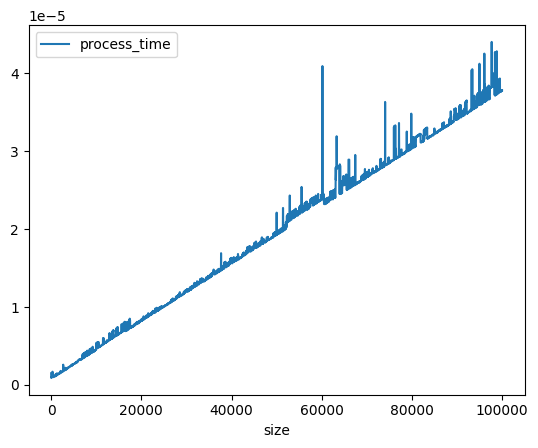

In [42]:
df.plot(x= "size", y= "process_time")